In [1]:
import tensorflow as tf
import numpy as np

In [8]:
import matplotlib.pyplot as plt

In [2]:
from models.cnn_model import CustomCNN
from utils.data_loader import load_and_preprocess, make_datasets, BATCH_SIZE

In [3]:
#Chargement du modele
model = tf.keras.models.load_model('Best_model.keras', custom_objects={'CustomCNN': CustomCNN})

In [5]:
(x_train, y_train), (x_test, y_test) = load_and_preprocess()
train_ds, test_ds = make_datasets(x_train, y_train, x_test, y_test)

[Forme d'entrée] Train : (50000, 32, 32, 3) | Test : (10000, 32, 32, 3)
[Normalisation] Plage des pixels train — min: 0.0 | max: 1.0
[DATA] Batch size : 50 | Augmentation : activée sur train


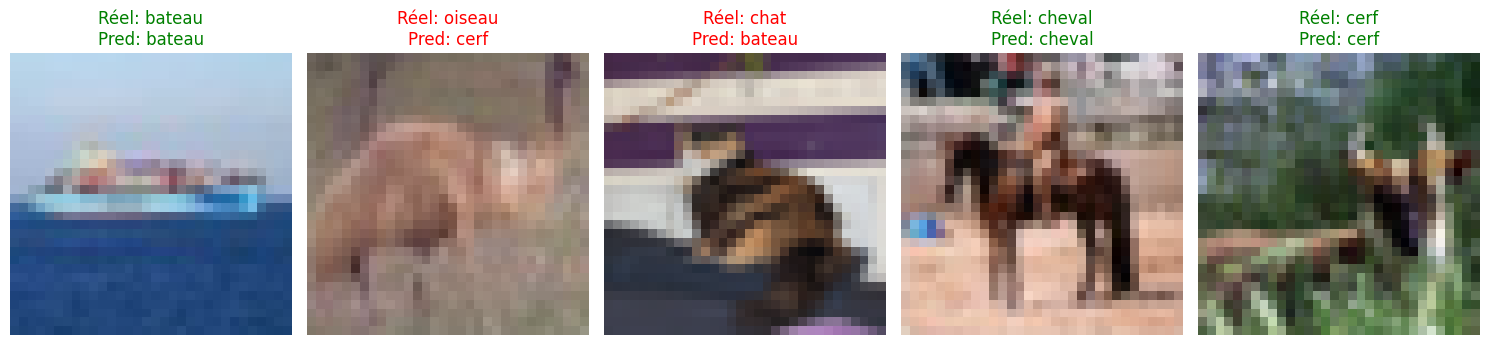

In [12]:
# 1. Sélectionner 5 indices au hasard
import random
indices = random.sample(range(len(x_test)), 5)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    img = x_test[idx]
    label_reel = y_test[idx][0] # [0] car y_test est souvent en 2D (n, 1)
    
    # 2. Prédiction
    img_input = np.expand_dims(img, axis=0)
    predictions = model.predict(img_input, verbose=0)
    classe_predite = np.argmax(predictions)
    
    # 3. Affichage
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    
    # Couleur du titre : vert si correct, rouge si erreur
    color = 'green' if classe_predite == label_reel else 'red'
    
    plt.title(f"Réel: {CLASS_NAMES[label_reel]}\nPred: {CLASS_NAMES[classe_predite]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

label de l'image est: [6]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Le modele pense que cest un: grenouille


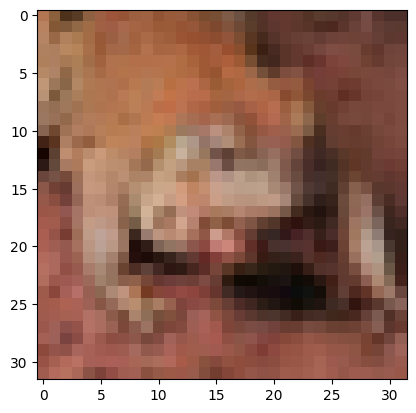

In [ ]:

img = x_test[]
plt.imshow(img)
print(f"label de l'image est: {y_test[5]}")
img_input = np.expand_dims(img, axis = 0)

predictions = model.predict(img_input)
classe_predite = np.argmax(predictions)

CLASS_NAMES = [
    "avion", "voiture", "oiseau", "chat", "cerf",
    "chien", "grenouille", "cheval", "bateau", "camion"
]
print(f"Le modele pense que cest un: {CLASS_NAMES[classe_predite]}")